In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
df = pd.read_csv('train.csv')

In [25]:
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

## **No missing values**
## **Data types are relevant**

In [27]:
df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849975,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


## **In 'num_lanes' columns the mean is bigger than median which indicates skewness**

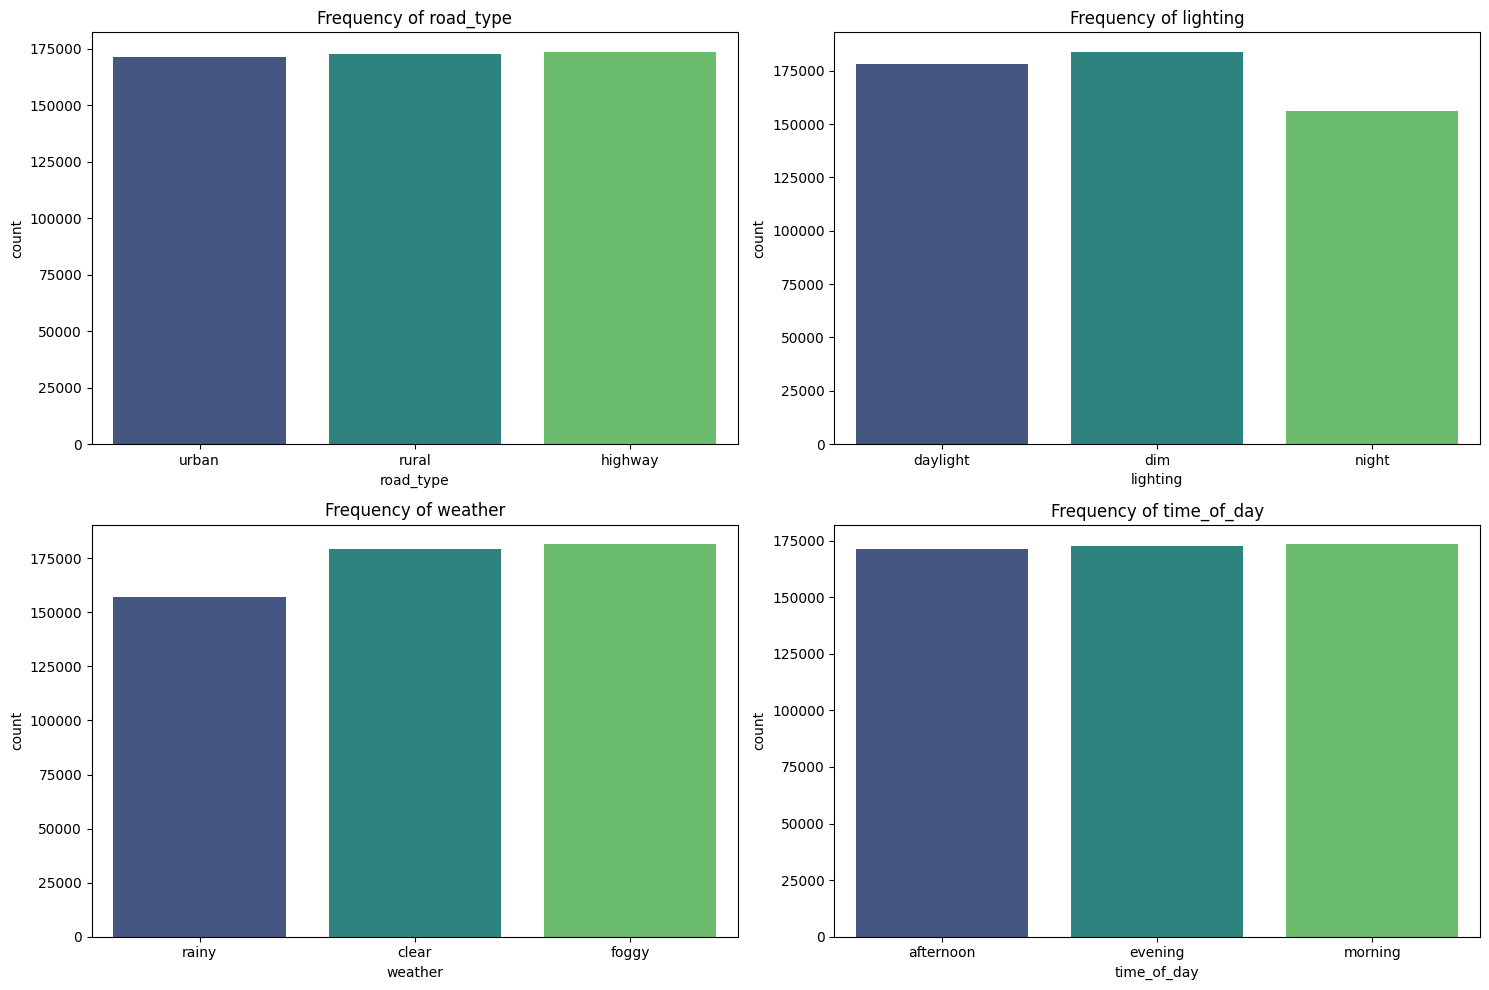

In [28]:
cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

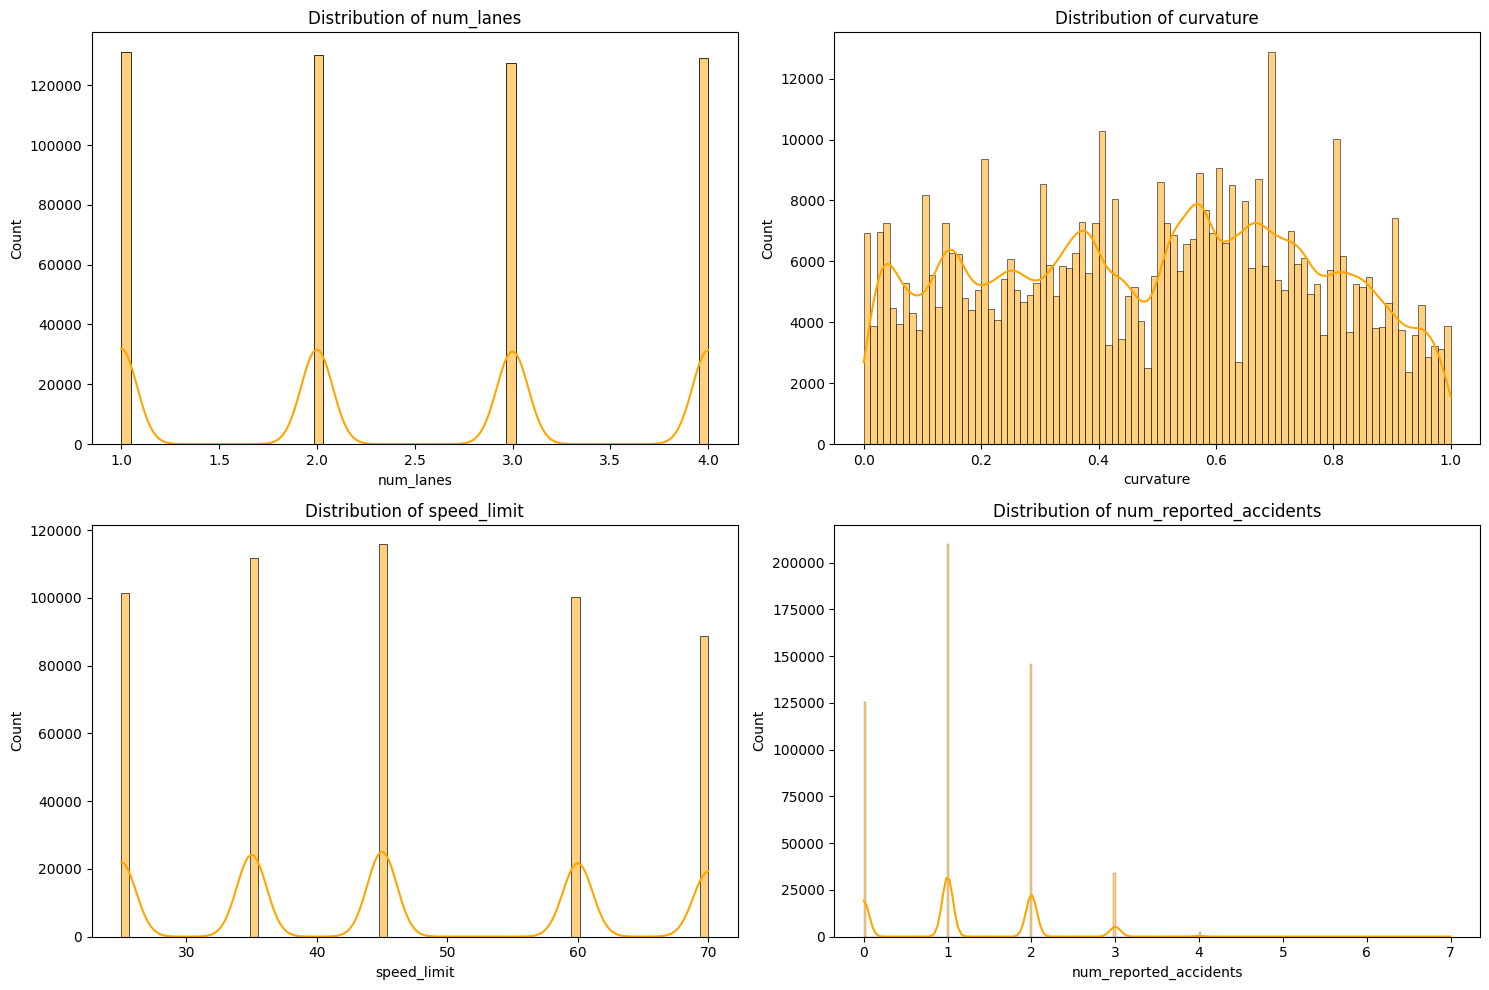

In [29]:
num_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='orange')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

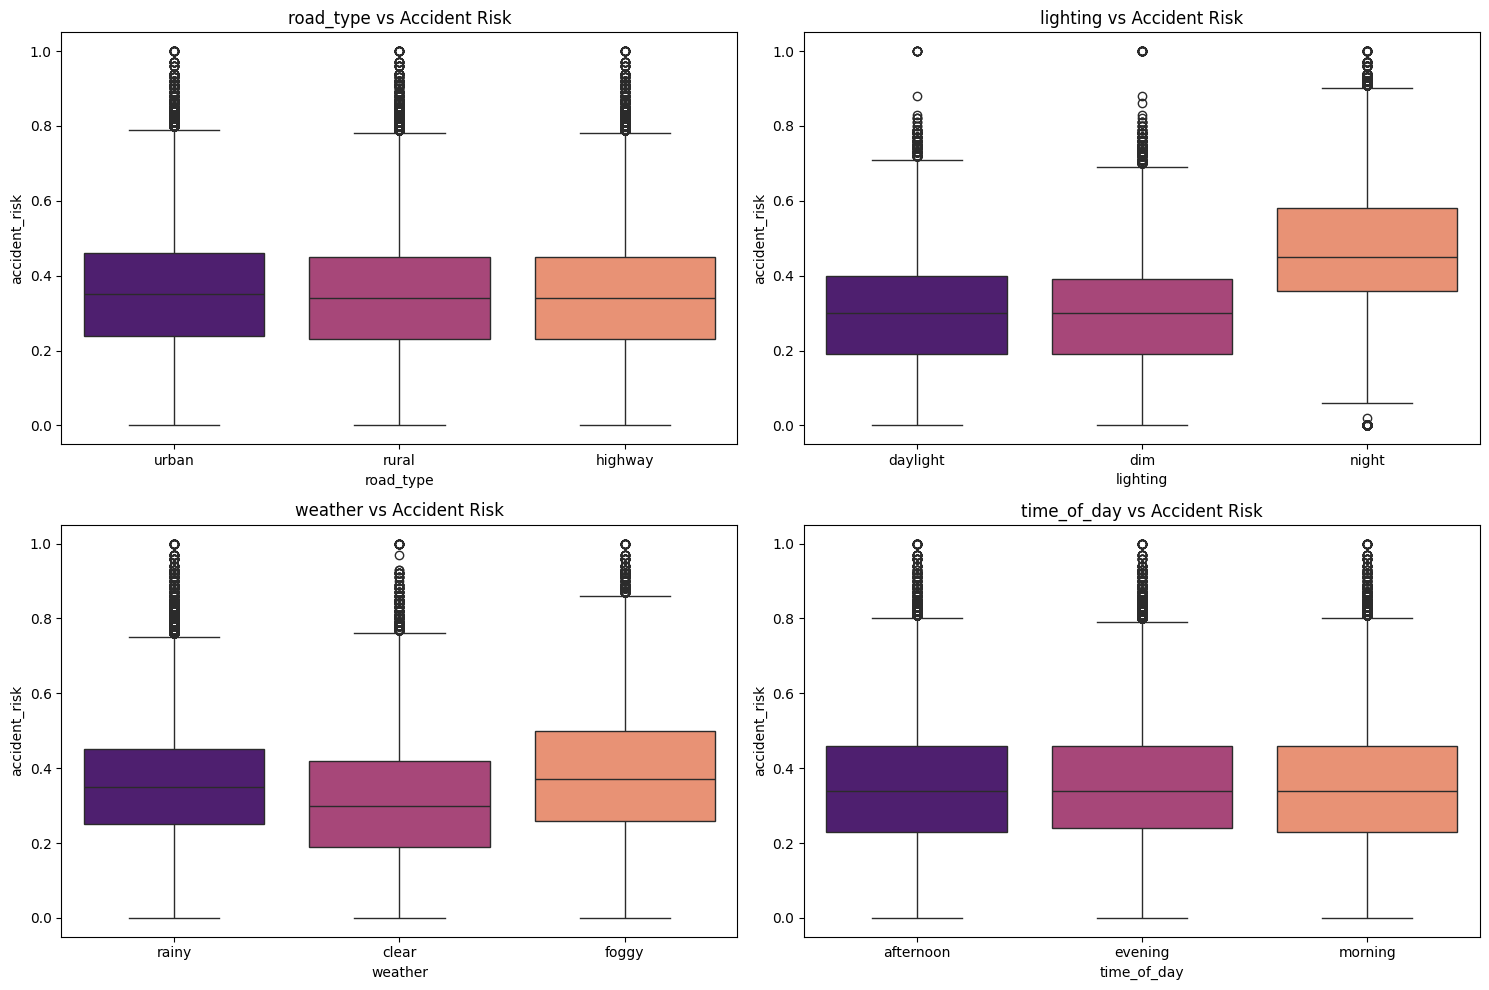

In [30]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y='accident_risk', palette='magma')
    plt.title(f'{col} vs Accident Risk')
plt.tight_layout()
plt.show()

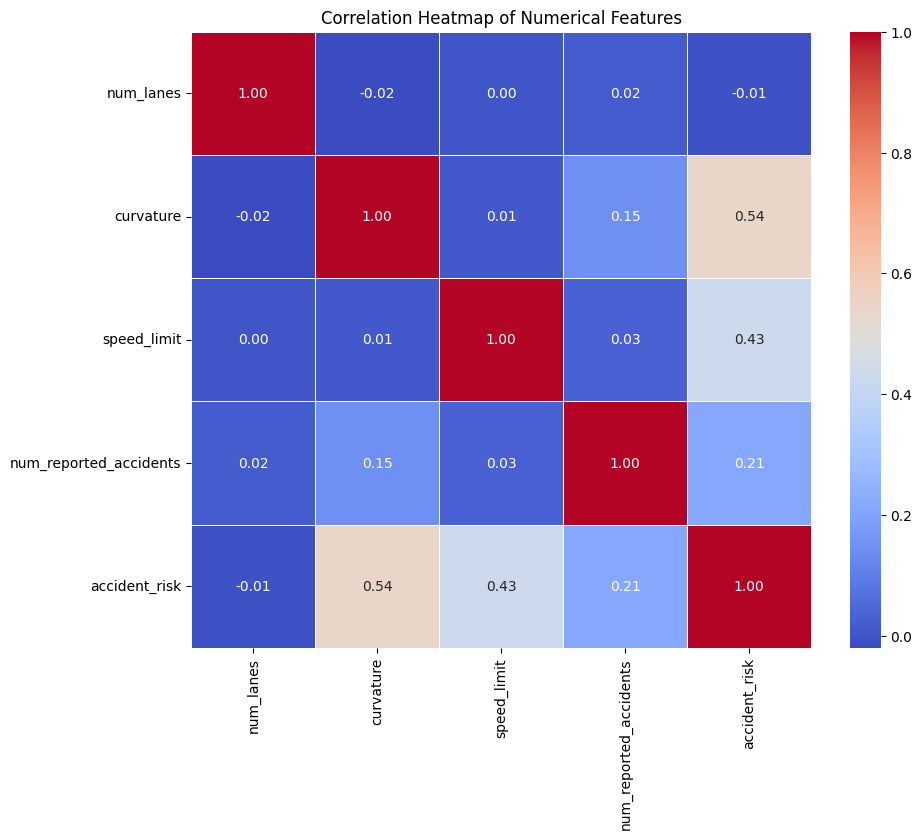

In [31]:
numerical_df = df.select_dtypes(include=['number']).drop(columns=['id'], errors='ignore')

corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

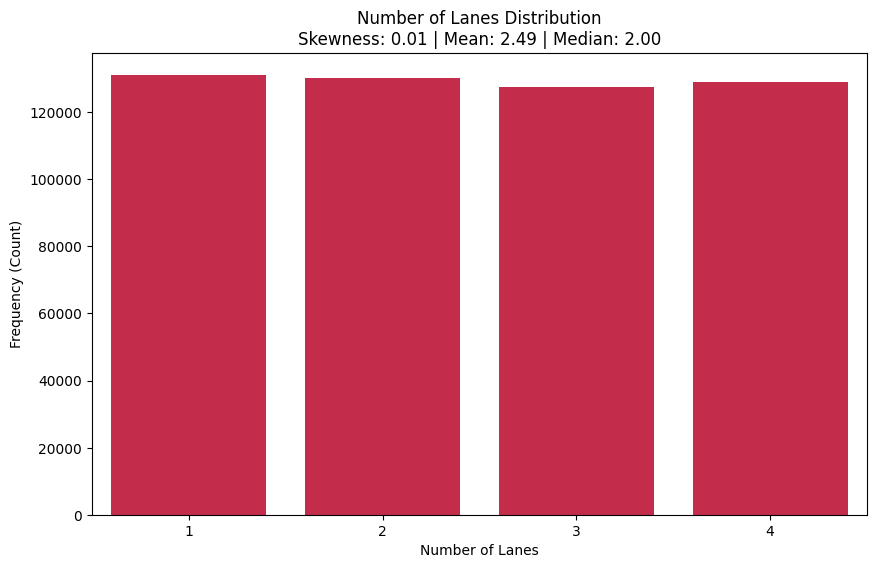

Skewness: 0.0128


In [32]:
skew_num_lanes = df['num_lanes'].skew()

plt.figure(figsize=(10, 6))
sns.countplot(x='num_lanes', data=df, color='crimson')

plt.title(f'Number of Lanes Distribution\nSkewness: {skew_num_lanes:.2f} | Mean: {df["num_lanes"].mean():.2f} | Median: {df["num_lanes"].median():.2f}')
plt.xlabel('Number of Lanes')
plt.ylabel('Frequency (Count)')

plt.show()
print(f"Skewness: {skew_num_lanes:.4f}")

## **Foggy weather and night lighting increase the accident risk**
## **No need for transformations as there isn't big skewness**
## **Some features doesn't have correlation with the target**

In [33]:
# Average risk per road type
print(df.groupby('road_type')['accident_risk'].mean())

road_type
highway    0.349734
rural      0.349997
urban      0.357456
Name: accident_risk, dtype: float64


In [34]:
bool_cols = ['road_signs_present', 'public_road', 'holiday', 'school_season']

for col in bool_cols:
    print(df.groupby(col)['accident_risk'].mean())

road_signs_present
False    0.352273
True     0.352482
Name: accident_risk, dtype: float64
public_road
False    0.347190
True     0.357518
Name: accident_risk, dtype: float64
holiday
False    0.343809
True     0.360827
Name: accident_risk, dtype: float64
school_season
False    0.352539
True     0.352214
Name: accident_risk, dtype: float64


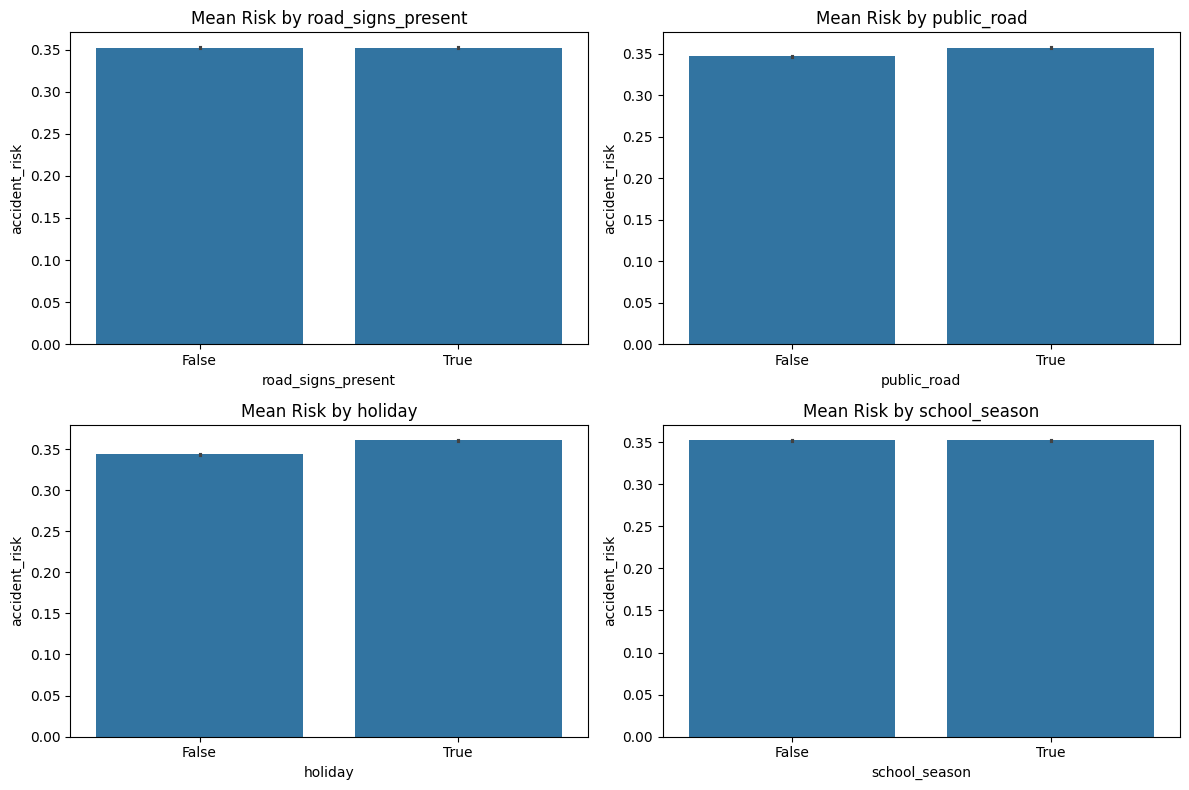

In [35]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(bool_cols, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=col, y='accident_risk')
    plt.title(f'Mean Risk by {col}')
plt.tight_layout()
plt.show()

## **Most of the categorical values aren't affecting the target**

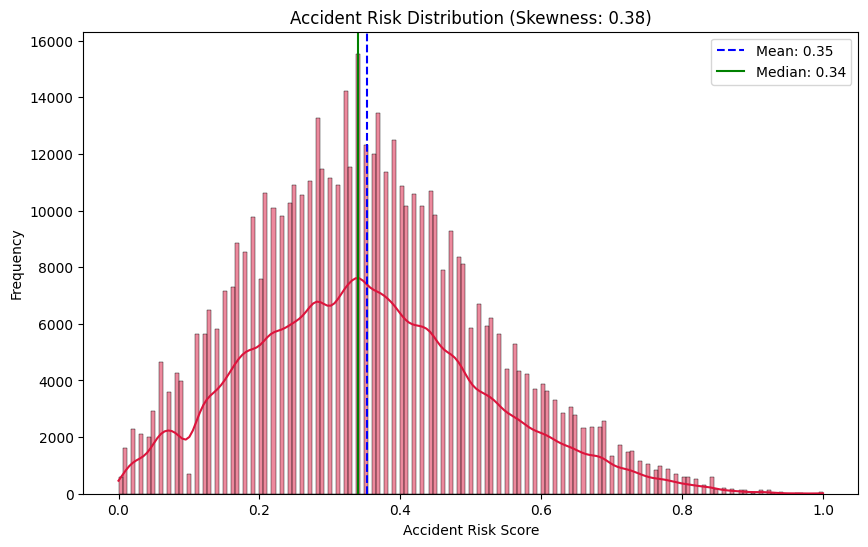

Numerical Skewness: 0.3784


In [36]:
skewness = df['accident_risk'].skew()
plt.figure(figsize=(10, 6))
sns.histplot(df['accident_risk'], kde=True, color='crimson')

plt.axvline(df['accident_risk'].mean(), color='blue', linestyle='--', label=f'Mean: {df["accident_risk"].mean():.2f}')
plt.axvline(df['accident_risk'].median(), color='green', linestyle='-', label=f'Median: {df["accident_risk"].median():.2f}')

plt.title(f'Accident Risk Distribution (Skewness: {skewness:.2f})')
plt.xlabel('Accident Risk Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Numerical Skewness: {skewness:.4f}")

## **The skewness of the target is small. No need for transformations**